# Categorical Encoding

In this tutorial you will learn to:
- Apply **binary encoding** for genuinely two-valued categories
- Apply **one-hot encoding** for nominal categories with no natural order
- Apply **ordinal encoding** when a category has a meaningful rank order
- Handle **out-of-vocabulary** categories that appear at prediction time but not in training
- Understand when **feature crosses** help vs. hurt

We'll work with a used-car sales dataset and encode its categorical columns — `Transmission`, `Fuel`, `Seller_Type`, and `Owner` — measuring the impact on a price model as we go.

> **Data source:** *Car Details from CarDekho* — used-car listings (specifications and asking prices) from CarDekho.com, published on Kaggle (e.g., the *Car Details Dataset* by Akshay Dattatray Khare).

---
## Theory: Why Encoding Matters

Machine learning models do arithmetic — they multiply, add, and compute distances. None of those operations are defined on strings, so every categorical feature (a fuel type, a transmission, an ownership level) must become numbers before a model can use it.

The naive approach is to assign integers: `Manual=0, Automatic=1`, or `First=0, Second=1, Third=2`. That works when the numbers reflect a real ordering (a third owner really does come after a first). When they don't — when the categories are just labels — assigning integers tells the model a false story. It will conclude that `Fuel=3` is three times `Fuel=1` and generalize on that nonsense.

The encoding must match the structure of the feature:
- **Binary (0/1)** — features that are genuinely two-valued
- **One-hot** — nominal categories: no order, no magnitude, just labels
- **Ordinal** — categories with a meaningful rank you want to preserve

---
## Step 1: Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.figsize'] = (10, 4)
sns.set_style('whitegrid')

RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [2]:
df = pd.read_csv('car_price.csv')
df = df.drop_duplicates().reset_index(drop=True)

# Derive car age from the manufacturing year. The newest models are 2020, so we measure age
# relative to 2021 (newest year + 1); deriving it from the data keeps results reproducible.
REFERENCE_YEAR = df['Year'].max() + 1
df['car_age'] = REFERENCE_YEAR - df['Year']

target = 'Selling_Price'
numerical_features = ['car_age', 'KM_Driven']
categorical_cols = ['Fuel', 'Seller_Type', 'Transmission', 'Owner']

print(f'Shape: {df.shape}\n')
for col in categorical_cols:
    print(f'{col} ({df[col].nunique()} unique): {list(df[col].unique())}')

Shape: (3577, 10)

Fuel (5 unique): ['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Seller_Type (3 unique): ['Individual', 'Dealer', 'Trustmark Dealer']
Transmission (2 unique): ['Manual', 'Automatic']
Owner (5 unique): ['First Owner', 'Second Owner', 'Fourth & Above Owner', 'Third Owner', 'Test Drive Car']


4


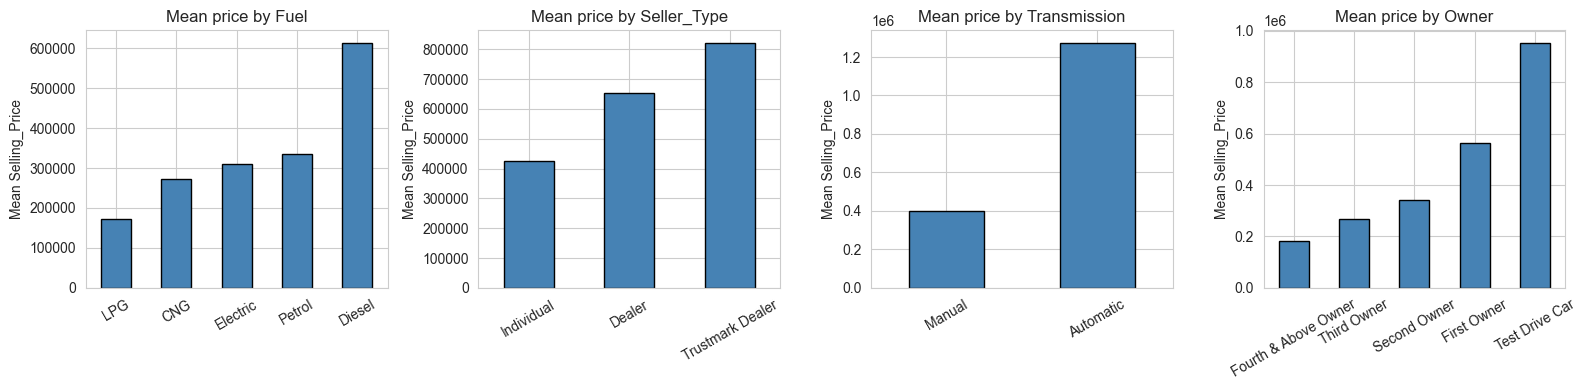

In [7]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(16, 4))
print(len(categorical_cols))
for ax, col in zip(axes, categorical_cols):
    df.groupby(col, observed=True)[target].mean().sort_values().plot(
        kind='bar', ax=ax, color='steelblue', edgecolor='black'
    )
    ax.set_title(f'Mean price by {col}')
    ax.set_ylabel('Mean Selling_Price')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

> **Observation**: `Transmission` separates prices sharply (Automatic cars sell far higher on average), and `Fuel` and `Seller_Type` both vary in clear ways. `Owner` shows a clean trend tied to how many previous owners a car has had. All four columns carry signal worth encoding.

In [8]:
# Baseline: numerical features only
X_num = df[numerical_features].copy()
y = np.log1p(df[target].values)

X_num_train, X_num_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=RANDOM_SEED)

# Clip KM_Driven outliers: threshold from training data only, then apply to all splits
km_p99 = X_num_train['KM_Driven'].quantile(0.99)
X_num_train['KM_Driven'] = X_num_train['KM_Driven'].clip(upper=km_p99)
X_num_test['KM_Driven'] = X_num_test['KM_Driven'].clip(upper=km_p99)
df['KM_Driven'] = df['KM_Driven'].clip(upper=km_p99)   # keep df consistent for later cells

scaler = StandardScaler()
model = LinearRegression()
model.fit(scaler.fit_transform(X_num_train), y_train)
baseline_rmse = rmse(y_test, model.predict(scaler.transform(X_num_test)))
print(f'Baseline RMSE (2 numerical features): {baseline_rmse:.4f}')

results = {'Numerical only (baseline)': baseline_rmse}

Baseline RMSE (2 numerical features): 0.5718


---
## Step 2: Binary Encoding

The simplest case: a feature with exactly two values. `Transmission` is either `Manual` or `Automatic`. Binary encoding maps one value to 0 and the other to 1 — no ordering is implied, because with two values there is only one split to make.

In [9]:
df_enc = df.copy()
df_enc['transmission_num'] = (df_enc['Transmission'] == 'Automatic').astype(int)

print(df_enc[['Transmission', 'transmission_num']].head(8))
print(f"\nMean price - Manual:    {df_enc.loc[df_enc['transmission_num']==0, target].mean():,.0f}")
print(f"Mean price - Automatic: {df_enc.loc[df_enc['transmission_num']==1, target].mean():,.0f}")

  Transmission  transmission_num
0       Manual                 0
1       Manual                 0
2       Manual                 0
3       Manual                 0
4       Manual                 0
5       Manual                 0
6       Manual                 0
7       Manual                 0

Mean price - Manual:    397,366
Mean price - Automatic: 1,274,955


In [10]:
features_with_binary = numerical_features + ['transmission_num']

X_b = df_enc[features_with_binary].copy()
y_b = np.log1p(df_enc[target].values)

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_b, y_b, test_size=0.2, random_state=RANDOM_SEED)
scaler_b = StandardScaler()
model.fit(scaler_b.fit_transform(X_b_train), y_b_train)
rmse_b = rmse(y_b_test, model.predict(scaler_b.transform(X_b_test)))
results['Numerical + Transmission'] = rmse_b

print(f'Baseline RMSE:                         {baseline_rmse:.4f}')
print(f'RMSE with binary-encoded transmission: {rmse_b:.4f}')
print(f'Change: {rmse_b - baseline_rmse:+.4f}')

Baseline RMSE:                         0.5718
RMSE with binary-encoded transmission: 0.5231
Change: -0.0487


> **Note**: Binary encoding a high-signal feature the model previously couldn't see gives it information it had no other way to access. Automatic cars sell at a different price level, and a single 0/1 column lets the model use that.

---
## Step 3: One-Hot Encoding

`Fuel` has several unordered values (`Diesel`, `Petrol`, `CNG`, `LPG`, `Electric`). Assigning integers 0–4 would impose an order and spacing that fuel types don't have — telling the model that `Electric` is somehow "more than" `Diesel`. Instead we create one binary column per category — each row has a 1 in exactly one column.

This is **one-hot encoding**: exactly one position is "hot" (1) at a time.

In [14]:
# pd.get_dummies — quick and handy for EDA (not for production pipelines)
fuel_dummies = pd.get_dummies(df['Fuel'], prefix='Fuel')
print(fuel_dummies.head(6))

   Fuel_CNG  Fuel_Diesel  Fuel_Electric  Fuel_LPG  Fuel_Petrol
0     False        False          False     False         True
1     False        False          False     False         True
2     False         True          False     False        False
3     False        False          False     False         True
4     False         True          False     False        False
5     False        False          False     False         True


In [17]:
# Production approach: sklearn OneHotEncoder.
# It learns the vocabulary from training data, handles unknowns, and fits inside a Pipeline.

# Split first, then fit the encoder on training rows only
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=RANDOM_SEED)
fuel_train = df.loc[train_idx, ['Fuel']]
fuel_test = df.loc[test_idx, ['Fuel']]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
fuel_train_enc = ohe.fit_transform(fuel_train)
fuel_test_enc = ohe.transform(fuel_test)

print(f'Fuel categories learned from training: {ohe.categories_[0]}')
print(f'Encoded training matrix shape: {fuel_train_enc.shape}\n')
print(pd.DataFrame(fuel_train_enc, columns=ohe.get_feature_names_out(['Fuel'])).head())

Fuel categories learned from training: ['CNG' 'Diesel' 'Electric' 'LPG' 'Petrol']
Encoded training matrix shape: (2861, 5)

   Fuel_CNG  Fuel_Diesel  Fuel_Electric  Fuel_LPG  Fuel_Petrol
0       0.0          1.0            0.0       0.0          0.0
1       0.0          0.0            0.0       0.0          1.0
2       0.0          1.0            0.0       0.0          0.0
3       0.0          1.0            0.0       0.0          0.0
4       0.0          1.0            0.0       0.0          0.0


In [55]:
# The dummy-variable trap: with k categories the k one-hot columns are linearly
# dependent (if all the others are 0, the row must be the remaining category).
# Dropping one column removes that redundancy; many linear models prefer it.
ohe_drop = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
fuel_drop_enc = ohe_drop.fit_transform(fuel_train)

print(f'Without drop:      {fuel_train_enc.shape[1]} columns')
print(f'With drop="first": {fuel_drop_enc.shape[1]} columns')
print(f'Kept columns: {ohe_drop.get_feature_names_out(["Fuel"])}')

Without drop:      5 columns
With drop="first": 4 columns
Kept columns: ['Fuel_Diesel' 'Fuel_Electric' 'Fuel_LPG' 'Fuel_Petrol']


In [26]:
# Combine numerical + binary(transmission) + one-hot(Fuel); train and evaluate
num_bin_cols = ['car_age', 'KM_Driven', 'transmission_num']
X_nb_train = df_enc.loc[train_idx, num_bin_cols].values
X_nb_test = df_enc.loc[test_idx, num_bin_cols].values

X_combined_train = np.hstack([X_nb_train, fuel_train_enc])
X_combined_test = np.hstack([X_nb_test, fuel_test_enc])

y_vals = np.log1p(df[target].values)
y_train_vals, y_test_vals = y_vals[train_idx], y_vals[test_idx]

scaler_c = StandardScaler()
model.fit(scaler_c.fit_transform(X_combined_train), y_train_vals)
rmse_ohe = rmse(y_test_vals, model.predict(scaler_c.transform(X_combined_test)))
results['Numerical + Transmission + Fuel'] = rmse_ohe

print(f'Baseline:                {baseline_rmse:.4f}')
print(f'+ binary (transmission): {rmse_b:.4f}')
print(f'+ one-hot Fuel:          {rmse_ohe:.4f}')

Baseline:                0.5718
+ binary (transmission): 0.5231
+ one-hot Fuel:          0.4658


---
## Step 4: Ordinal Encoding

When a categorical feature has a **natural rank order** that matters for the prediction, ordinal encoding preserves that order in a single column instead of creating many binary ones.

`Owner` is a genuine ordinal feature: `First Owner`, `Second Owner`, `Third Owner`, `Fourth & Above Owner` — each step is one more previous owner. The dataset also has `Test Drive Car` (a dealer demo car, essentially zero private owners), which sits naturally at the start of that scale.

In [28]:
print('Owner value counts:')
print(df['Owner'].value_counts())

# Order by number of previous owners (Test Drive ~ 0, then First, Second, ...)
owner_order = ['Test Drive Car', 'First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner']

Owner value counts:
Owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64


In [29]:
ord_enc = OrdinalEncoder(categories=[owner_order])
ord_enc_default = OrdinalEncoder()   # sorts alphabetically — wrong here

sample = pd.DataFrame({'Owner': owner_order})
print('Correct order (by number of owners):')
print(pd.DataFrame({'Owner': sample['Owner'],
                    'encoded': ord_enc.fit_transform(sample).flatten().astype(int)}))
print('\nDefault (alphabetical — WRONG):')
print(pd.DataFrame({'Owner': sample['Owner'],
                    'encoded': ord_enc_default.fit_transform(sample).flatten().astype(int)}))

Correct order (by number of owners):
                  Owner  encoded
0        Test Drive Car        0
1           First Owner        1
2          Second Owner        2
3           Third Owner        3
4  Fourth & Above Owner        4

Default (alphabetical — WRONG):
                  Owner  encoded
0        Test Drive Car        3
1           First Owner        0
2          Second Owner        2
3           Third Owner        4
4  Fourth & Above Owner        1


In [34]:
# Encode Owner with the correct order and add it to the model
df_ord = df_enc.copy()
df_ord['owner_ord'] = OrdinalEncoder(categories=[owner_order]).fit_transform(df_ord[['Owner']])

feat_ord = ['car_age', 'KM_Driven', 'transmission_num', 'owner_ord']
Xo = df_ord[feat_ord].values
yo = np.log1p(df_ord[target].values)
Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(Xo, yo, test_size=0.2, random_state=RANDOM_SEED)
scaler_o = StandardScaler()
model.fit(scaler_o.fit_transform(Xo_tr), yo_tr)
rmse_ord = rmse(yo_te, model.predict(scaler_o.transform(Xo_te)))
results['Numerical + Transmission + Owner'] = rmse_ord
print(f'+ ordinal Owner: RMSE = {rmse_ord:.4f}  (baseline {baseline_rmse:.4f})')

+ ordinal Owner: RMSE = 0.5224  (baseline 0.5718)


In [35]:
# Quick rule of thumb: ordinal vs one-hot
#
#   Ordinal:  First < Second < Third < Fourth owner   (rank is real)
#             Low < Medium < High                      (labels imply magnitude)
#             Cold < Warm < Hot                        (ordered)
#
#   One-hot:  Petrol, Diesel, CNG, Electric            (no ranking among fuels)
#             Red, Green, Blue                         (colours have no rank)
#             Brand names, postal codes                (arbitrary labels)

print('Use ordinal encoding when the RANK is meaningful to the prediction task.')
print('If you would not say "category A is more than category B", use one-hot instead.')

Use ordinal encoding when the RANK is meaningful to the prediction task.
If you would not say "category A is more than category B", use one-hot instead.


---
## Step 5: Handling Out-of-Vocabulary (OOV) Categories

When you deploy a model, the real world sometimes sends a category that was never in your training data — a new car brand, a fuel type you hadn't seen, a region added after you collected data. This is the **out-of-vocabulary** (OOV) problem. If your encoder has no strategy for it, it will either crash or produce garbage.

This dataset has a built-in example: `Brand` has 29 values and `Fuel` includes `Electric` with just one listing — either could easily be absent from a training split and then show up at prediction time.

In [38]:
# Default OneHotEncoder raises on unknown categories
ohe_strict = OneHotEncoder(sparse_output=False)
ohe_strict.fit(pd.DataFrame({'Fuel': ['Petrol', 'Diesel', 'CNG', 'LPG']}))

new_data = pd.DataFrame({'Fuel': ['Petrol', 'Electric']})   # 'Electric' is unseen
try:
    ohe_strict.transform(new_data)
except ValueError as e:
    print(f'Error (default behavior): {e}')

Error (default behavior): Found unknown categories ['Electric'] in column 0 during transform


In [39]:
# Fix: handle_unknown='ignore' — an unknown category becomes all zeros
ohe_safe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_safe.fit(pd.DataFrame({'Fuel': ['Petrol', 'Diesel', 'CNG', 'LPG']}))

result = ohe_safe.transform(new_data)
print("handle_unknown='ignore' — unknown row becomes all zeros:")
print(pd.DataFrame(result, columns=ohe_safe.get_feature_names_out(['Fuel'])))
print('\nThe "Electric" row is all zeros — treated as "none of the known categories".')

handle_unknown='ignore' — unknown row becomes all zeros:
   Fuel_CNG  Fuel_Diesel  Fuel_LPG  Fuel_Petrol
0       0.0          0.0       0.0          1.0
1       0.0          0.0       0.0          0.0

The "Electric" row is all zeros — treated as "none of the known categories".


> **Production note**: OOV categories are common in live systems. Always set `handle_unknown='ignore'` as a minimum safeguard, and log when unknown values appear — frequent OOVs are a signal your training data is going stale and the model should be retrained.

---
## Step 6: Feature Crosses

A **feature cross** combines two categorical features into one that captures their joint effect. `Automatic` + `Diesel` might behave differently from `Automatic` + `Petrol` in a way neither column captures alone.

The cost is **dimensionality**: features with `m` and `n` values cross into `m × n` combinations.

In [48]:
df_cross = df.copy()
df_cross['transmission_fuel'] = df_cross['Transmission'] + '_' + df_cross['Fuel']

print(f"Transmission values: {df['Transmission'].nunique()}")
print(f"Fuel values:         {df['Fuel'].nunique()}")
print(f"Cross combinations:  {df_cross['transmission_fuel'].nunique()}")
print(f"\nCombinations present:\n{sorted(df_cross['transmission_fuel'].unique())}")

Transmission values: 2
Fuel values:         5
Cross combinations:  7

Combinations present:
['Automatic_Diesel', 'Automatic_Electric', 'Automatic_Petrol', 'Manual_CNG', 'Manual_Diesel', 'Manual_LPG', 'Manual_Petrol']


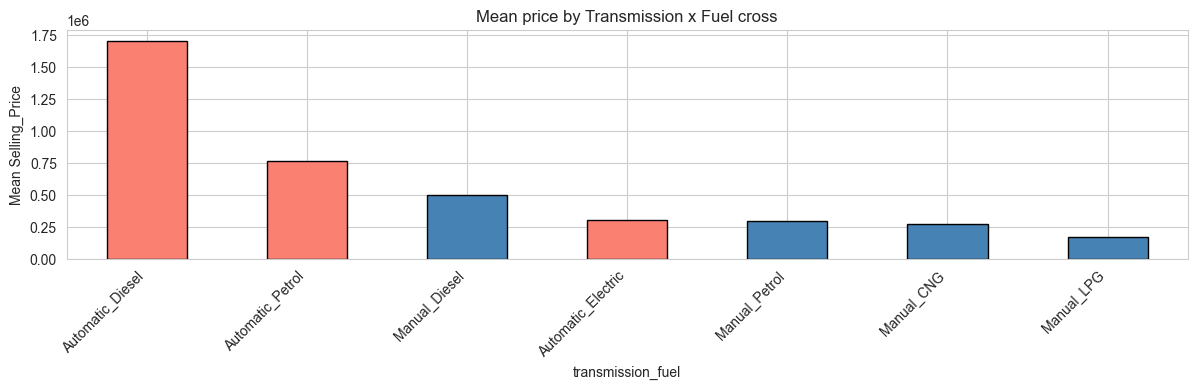

Red = Automatic, Blue = Manual


In [49]:
cross_means = df_cross.groupby('transmission_fuel', observed=True)[target].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
cross_means.plot(kind='bar',
                 color=['salmon' if x.startswith('Automatic') else 'steelblue' for x in cross_means.index],
                 edgecolor='black')
plt.title('Mean price by Transmission x Fuel cross')
plt.ylabel('Mean Selling_Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Red = Automatic, Blue = Manual')

In [50]:
print('Dimensionality of feature crosses:')
print(f'  Transmission (2) x Fuel (5) = {2*5} possible combinations ({df_cross["transmission_fuel"].nunique()} actually occur here)')
print(f'  Brand (29) x Fuel (5)       = {29*5} possible combinations')
print(f'  brand (500) x store (200)   = {500*200:,} possible columns (mostly empty)')
print()
print('Crosses are worth it when:')
print('  1. You have a domain reason the combination matters')
print('  2. The resulting column count stays manageable')
print('  3. Each combination has enough rows to learn from (sparse combos are noise)')

Dimensionality of feature crosses:
  Transmission (2) x Fuel (5) = 10 possible combinations (7 actually occur here)
  Brand (29) x Fuel (5)       = 145 possible combinations
  brand (500) x store (200)   = 100,000 possible columns (mostly empty)

Crosses are worth it when:
  1. You have a domain reason the combination matters
  2. The resulting column count stays manageable
  3. Each combination has enough rows to learn from (sparse combos are noise)


---
## Step 7: Full Pipeline — All Encodings Together

Now we combine everything: numerical features (scaled) + binary `Transmission` + one-hot `Fuel` and `Seller_Type` + ordinal `Owner`, and compare against the numerical-only baseline.

**Reading the comparison below:** the two middle rows (`Numerical + Transmission + Fuel` and `Numerical + Transmission + Owner`) are *separate* models — each adds a single encoding to the `Numerical + Transmission` features, so you can see what each contributes on its own. The `Owner` model scoring higher than the `Fuel` model doesn't mean `Owner` hurt — it just adds less signal. Only the final row stacks all four encodings together.

In [42]:
df_full = df.copy()
df_full['transmission_num'] = (df_full['Transmission'] == 'Automatic').astype(int)

y_full = np.log1p(df_full[target].values)
idx_train, idx_test = train_test_split(np.arange(len(df_full)), test_size=0.2, random_state=RANDOM_SEED)

# One-hot Fuel + Seller_Type, fit on train only
ohe_full = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_cols_ohe = ['Fuel', 'Seller_Type']
ohe_full.fit(df_full.loc[idx_train, cat_cols_ohe])
ohe_train = ohe_full.transform(df_full.loc[idx_train, cat_cols_ohe])
ohe_test = ohe_full.transform(df_full.loc[idx_test, cat_cols_ohe])

# Ordinal Owner (explicit order)
df_full['owner_ord'] = OrdinalEncoder(categories=[owner_order]).fit_transform(df_full[['Owner']])

# Numerical + binary + ordinal
base_cols = ['car_age', 'KM_Driven', 'transmission_num', 'owner_ord']
X_base_train = df_full.loc[idx_train, base_cols].values
X_base_test = df_full.loc[idx_test, base_cols].values

X_full_train = np.hstack([X_base_train, ohe_train])
X_full_test = np.hstack([X_base_test, ohe_test])

scaler_full = StandardScaler()
model.fit(scaler_full.fit_transform(X_full_train), y_full[idx_train])
rmse_full = rmse(y_full[idx_test], model.predict(scaler_full.transform(X_full_test)))
results['All four encodings'] = rmse_full

feature_names = base_cols + list(ohe_full.get_feature_names_out(cat_cols_ohe))
print(f'Feature count: {X_full_train.shape[1]}\n')
print('RMSE comparison (log scale — each row is its own model):')
for name, r in results.items():
    print(f'  {name:34s}: {r:.4f}')

Feature count: 12

RMSE comparison (log scale — each row is its own model):
  Numerical only (baseline)         : 0.5718
  Numerical + Transmission          : 0.5231
  Numerical + Transmission + Fuel   : 0.4658
  Numerical + Transmission + Owner  : 0.5224
  All four encodings                : 0.4610


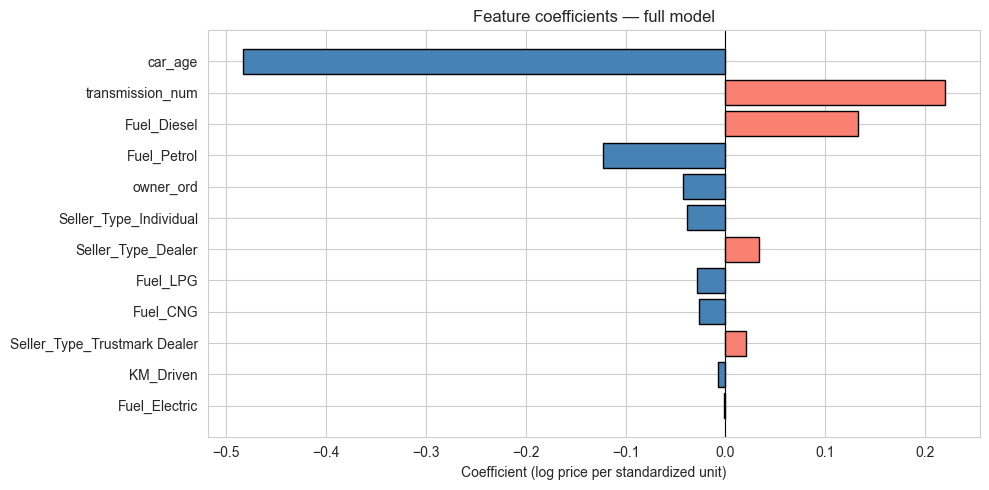

Positive = pushes predicted price up | Negative = pushes it down


In [47]:
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': model.coef_})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(10, 5))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient (log price per standardized unit)')
plt.title('Feature coefficients — full model')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print('Positive = pushes predicted price up | Negative = pushes it down')

---
## YOUR TURN

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

**Exercise: Encoding decisions in practice**

Below are five features from different datasets. For each, decide which encoding to use (binary 0/1, one-hot, or ordinal) and write a one-sentence justification.

| Feature | Values | Your encoding choice | Why? |
|---|---|---|---|
| `email_verified` | yes / no | Binary encoding | it has only two categories |
| `property_type` | Apartment, House, Condo, Townhouse, Villa | One-hot encoding | it has 5 categories and the rank is not meaningful |
| `credit_rating` | Poor, Fair, Good, Very Good, Exceptional | Ordinal encoding | in this case, the rank is meaningful |
| `day_of_week` | Monday, Tuesday, ..., Sunday | One-hot encoding | it has 7 categories and the rank is not meaningful |
| `continent` | Africa, Asia, Europe, North America, South America, Oceania | One-hot encoding | the rank is not meaningful |

Then implement one encoding of your choice on this car dataset (for example, one-hot `Seller_Type` on its own, or a `Transmission × Fuel` cross) and measure its impact on RMSE.

</div>

In [ ]:
# YOUR TURN
# Part 1: fill in the encoding table above

# Part 2: choose one encoding and test its impact on the car-price model
# Ideas:
#  - one-hot Seller_Type and add it to the baseline
#  - build the Transmission x Fuel cross and one-hot encode it
#  - drop a feature and see whether the model changes

df_your = df.copy()
column_to_encode = 'Seller_Type'
print(f'{column_to_encode} ({df[column_to_encode].nunique()} unique): {list(df[column_to_encode].unique())}')
seller_dummies = pd.get_dummies(df['Seller_Type'], prefix='Seller')
print(seller_dummies.head(6))


# ... your encoding ...
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=RANDOM_SEED)
seller_train = df.loc[train_idx, ['Seller_Type']]
seller_test = df.loc[test_idx, ['Seller_Type']]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
seller_train_enc = ohe.fit_transform(seller_train)
seller_test_enc = ohe.transform(seller_test)

print(f'Seller_Type categories learned from training: {ohe.categories_[0]}')
print(f'Encoded training matrix shape: {seller_train_enc.shape}\n')

X_nb_train = df_enc.loc[train_idx, num_bin_cols].values
X_nb_test = df_enc.loc[test_idx, num_bin_cols].values

X_combined_train = np.hstack([X_nb_train, seller_train_enc])
X_combined_test = np.hstack([X_nb_test, seller_test_enc])

y_vals = np.log1p(df[target].values)
y_train_vals, y_test_vals = y_vals[train_idx], y_vals[test_idx]

# ... your model ...
scaler_c = StandardScaler()
model.fit(scaler_c.fit_transform(X_combined_train), y_train_vals)
rmse_val = rmse(y_test_vals, model.predict(scaler_c.transform(X_combined_test)))
print(f'Baseline:                {baseline_rmse:.4f}')
print(f'RMSE:                    {rmse_val:.4f}')

Seller_Type (3 unique): ['Individual', 'Dealer', 'Trustmark Dealer']
   Seller_Dealer  Seller_Individual  Seller_Trustmark Dealer
0          False               True                    False
1          False               True                    False
2          False               True                    False
3          False               True                    False
4          False               True                    False
5          False               True                    False
Seller_Type categories learned from training: ['Dealer' 'Individual' 'Trustmark Dealer']
Encoded training matrix shape: (2861, 2)

Baseline:                0.5718
RMSE:                    0.5183


<details><summary><b>Click for Encoding Table Answers</b></summary>

| Feature | Recommended encoding | Reason |
|---|---|---|
| `email_verified` | Binary (0/1) | Exactly two values — no ordering question arises |
| `property_type` | One-hot | Nominal: no natural rank among Apartment, House, Condo, etc. |
| `credit_rating` | Ordinal | Genuine rank: Poor < Fair < Good < Very Good < Exceptional |
| `day_of_week` | Depends | If cyclical patterns matter (Sun ≈ Mon), use cyclical (sin/cos) encoding; if treated as 7 unordered labels, one-hot. Ordinal is wrong — Sunday is not "more" than Monday. |
| `continent` | One-hot | Nominal: no ranking among continents |

When in doubt between one-hot and ordinal, ask whether a domain expert would naturally say "category A is *more* than category B." If not, use one-hot.

</details>

---
## Key Takeaways

1. **Encoding must match feature structure.** Binary for two-valued features, one-hot for unordered categories, ordinal for genuinely ranked ones. The wrong choice tells the model a false story.
2. **Fit encoders on training data only.** `OneHotEncoder.fit()` learns the vocabulary from training rows; `transform()` then applies it to both splits. Calling `fit()` on test data leaks information — the same rule as scalers and imputers.
3. **Handle OOV with `handle_unknown='ignore'`.** The real world will send categories you never trained on. All-zeros is a safe, neutral fallback — and you should log these so you know when to retrain.
4. **Feature crosses capture joint effects but grow dimensionality.** Two 10-category features cross into 100 columns, most of them sparse. Use a cross only with a domain reason and enough data.
5. **Encoding can close a large RMSE gap.** A high-signal categorical (like `Transmission` or `Owner`) that was previously unused can move the model meaningfully once encoded.